In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

In [ ]:
import os

print("Current Directory:")
print(os.getcwd())

In [ ]:
import os

print(os.getcwd())

In [ ]:
nav = pd.read_csv(
    "../../../data/processed/nav_history_clean.csv"
)

nav.head()

In [ ]:
import os

print(
    os.path.exists(
        "../../../data/processed/nav_history_clean.csv"
    )
)

In [ ]:
nav = pd.read_csv(
    "../../../data/processed/nav_history_clean.csv"
)

nav.head()

In [ ]:
nav["date"] = pd.to_datetime(nav["date"])

In [ ]:
print("Shape:", nav.shape)
print("Unique Funds:", nav["amfi_code"].nunique())

In [68]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of Mutual Fund Schemes (2022–2026)"
)

fig.show()

In [67]:
fig.add_vrect(
    x0="2023-01-01",
    x1="2023-12-31",
    fillcolor="green",
    opacity=0.15,
    annotation_text="2023 Bull Run",
    line_width=0
)

fig.show()

In [66]:
fig.add_vrect(
    x0="2024-01-01",
    x1="2024-12-31",
    fillcolor="red",
    opacity=0.15,
    annotation_text="2024 Correction",
    line_width=0
)

fig.show()

In [ ]:
fig.write_html("nav_trend.html")

In [65]:
import os

print(os.path.exists("nav_trend.html"))

True


In [64]:
avg_nav = (
    nav.groupby("amfi_code")["nav"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

In [69]:
nav["month"] = nav["date"].dt.to_period("M")

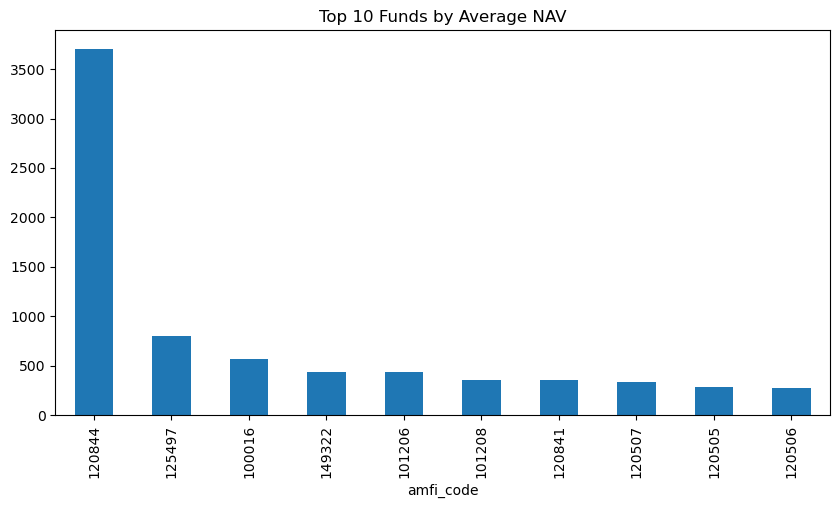

In [71]:
avg_nav = (
    nav.groupby("amfi_code")["nav"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_nav.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Funds by Average NAV")

plt.savefig("top10_avg_nav.png")

plt.show()

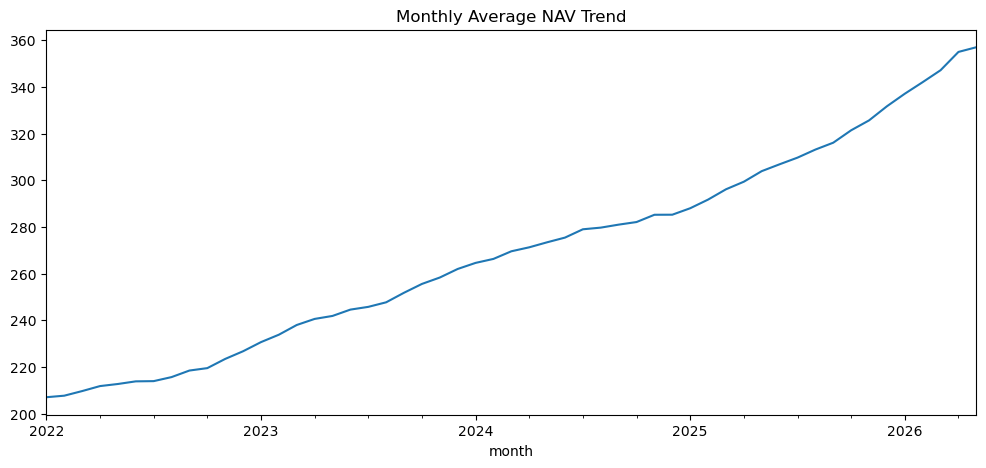

In [72]:
nav["month"] = nav["date"].dt.to_period("M")

monthly_nav = (
    nav.groupby("month")["nav"]
    .mean()
)

monthly_nav.plot(
    figsize=(12,5)
)

plt.title(
    "Monthly Average NAV Trend"
)

plt.savefig(
    "monthly_avg_nav.png"
)

plt.show()

## Insight 1


Most mutual fund schemes showed a strong upward NAV trend during 2023, reflecting a broad market bull run. Growth moderated during 2024 due to market corrections.

In [ ]:
aum = pd.read_csv(
    "../../../data/raw/03_aum_by_fund_house.csv"
)

aum.head()

In [ ]:
aum["date"] = pd.to_datetime(aum["date"])

aum.info()

In [ ]:
aum["year"] = aum["date"].dt.year

aum[["date", "year"]].head()

In [ ]:
print(aum["year"].unique())

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.show()

In [ ]:
plt.figure(figsize=(14,6))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022-2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")

plt.savefig(
    "aum_growth.png",
    bbox_inches="tight"
)

plt.show()

In [ ]:
import os

print(os.path.exists("aum_growth.png"))

## Insight 2

SBI Mutual Fund consistently maintained the highest AUM among major fund houses, demonstrating strong market leadership throughout 2022–2025.

In [ ]:
sip = pd.read_csv(
    "../../../data/raw/04_monthly_sip_inflows.csv"
)

sip.head()

In [ ]:
sip.shape

In [ ]:
sip["month"] = pd.to_datetime(
    sip["month"]
)

sip.info()

In [ ]:
max_row = sip.loc[
    sip["sip_inflow_crore"].idxmax()
]

print(max_row)

In [ ]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2025)",
    markers=True
)

fig.show()

In [ ]:
fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="₹31,002 Cr All-Time High",
    showarrow=True
)

fig.show()

In [ ]:
fig.write_html("sip_trend.html")

In [ ]:
import os

print(os.path.exists("sip_trend.html"))

In [ ]:
fig.write_image("sip_trend.png")

In [1]:
import pandas as pd
import plotly.express as px

sip = pd.read_csv("../../../data/raw/04_monthly_sip_inflows.csv")
sip["month"] = pd.to_datetime(sip["month"])

max_row = sip.loc[sip["sip_inflow_crore"].idxmax()]

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    title="Monthly SIP Inflows (2022–2025)",
    markers=True
)

fig.add_annotation(
    x=max_row["month"],
    y=max_row["sip_inflow_crore"],
    text="₹31,002 Cr All-Time High",
    showarrow=True
)

c:\Users\kakir\anaconda3\Lib\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.

You can however, use the Kaleido API directly which will work with your plotly version. `kaleido.write_fig(...)`, for example. Please see the kaleido documentation.




In [76]:
import pandas as pd

sip = pd.read_csv(
    "../../../data/raw/04_monthly_sip_inflows.csv"
)

sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


In [77]:
sip.columns

Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='object')

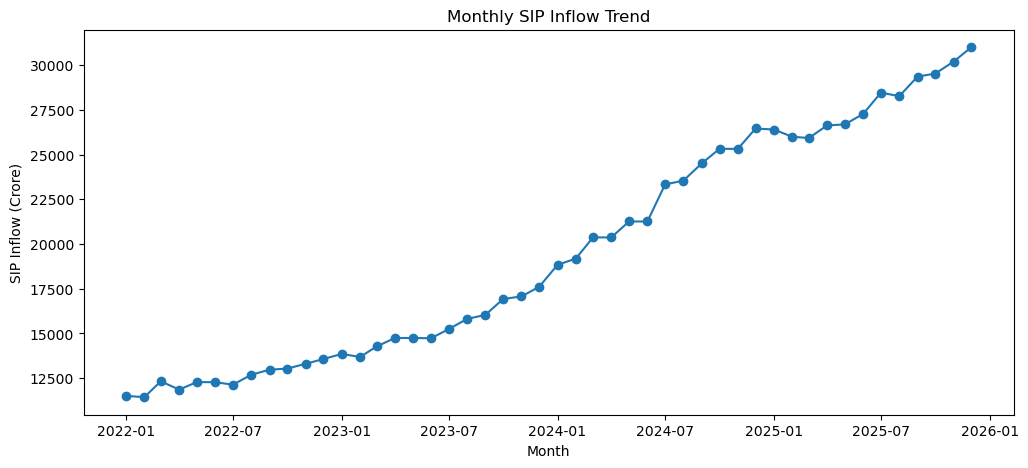

In [78]:
sip["month"] = pd.to_datetime(sip["month"])

plt.figure(figsize=(12,5))

plt.plot(
    sip["month"],
    sip["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflow Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.savefig(
    "sip_trend_matplotlib.png",
    bbox_inches="tight"
)

plt.show()

## Insight 3

Monthly SIP inflows showed a strong upward trend and reached an all-time high of ₹31,002 crore in December 2025, indicating growing retail participation in mutual funds.

In [5]:
import sys

print(sys.executable)
import kaleido

print(kaleido)

c:\Users\kakir\anaconda3\python.exe
<module 'kaleido' from 'c:\\Users\\kakir\\anaconda3\\Lib\\site-packages\\kaleido\\__init__.py'>


In [2]:
pip show kaleido

Name: kaleidoNote: you may need to restart the kernel to use updated packages.

Version: 1.3.0
Summary: Plotly graph export library
Home-page: https://github.com/plotly/kaleido
Author: 
Author-email: Andrew Pikul <ajpikul@gmail.com>, Neyberson Atencio <neyberatencio@gmail.com>
License: The MIT License (MIT)

Copyright (c) Plotly, Inc

Permission is hereby granted, free of charge, to any person obtaining a copy
of this software and associated documentation files (the "Software"), to deal
in the Software without restriction, including without limitation the rights
to use, copy, modify, merge, publish, distribute, sublicense, and/or sell
copies of the Software, and to permit persons to whom the Software is
furnished to do so, subject to the following conditions:

The above copyright notice and this permission notice shall be included in
all copies or substantial portions of the Software.

THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR
IMPLIED, INCLUDING BUT NOT

In [3]:
import sys
print(sys.executable)

c:\Users\kakir\anaconda3\python.exe


In [5]:
import pandas as pd
cat = pd.read_csv(
    "../../../data/raw/05_category_inflows.csv"
)

cat.head()

,month,category,net_inflow_crore
0,2024-04,Large Cap,2413.0
1,2024-04,Mid Cap,3897.0
2,2024-04,Small Cap,3533.0
3,2024-04,Flexi Cap,4947.0
4,2024-04,Large & Mid Cap,4214.0


In [6]:
heatmap_data = cat.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

heatmap_data.head()

month,2024-04,2024-05,2024-06,2024-07,2024-08,2024-09,2024-10,2024-11,2024-12,2025-01,2025-02,2025-03
category,,,,,,,,,,,,
ELSS,466.0,553.0,472.0,471.0,499.0,537.0,537.0,571.0,521.0,516.0,437.0,500.0
Flexi Cap,4947.0,5529.0,4478.0,4869.0,5562.0,5397.0,6004.0,6111.0,4654.0,5603.0,6068.0,4767.0
Gilt,784.0,836.0,864.0,959.0,952.0,925.0,898.0,704.0,831.0,744.0,942.0,956.0
Hybrid,2955.0,3487.0,3163.0,3291.0,3684.0,3015.0,3314.0,3264.0,3538.0,2967.0,3360.0,2830.0
Large & Mid Cap,4214.0,4368.0,4610.0,5023.0,5411.0,4528.0,4581.0,5556.0,4878.0,4816.0,5524.0,4243.0


In [7]:
heatmap_data.shape

(12, 12)

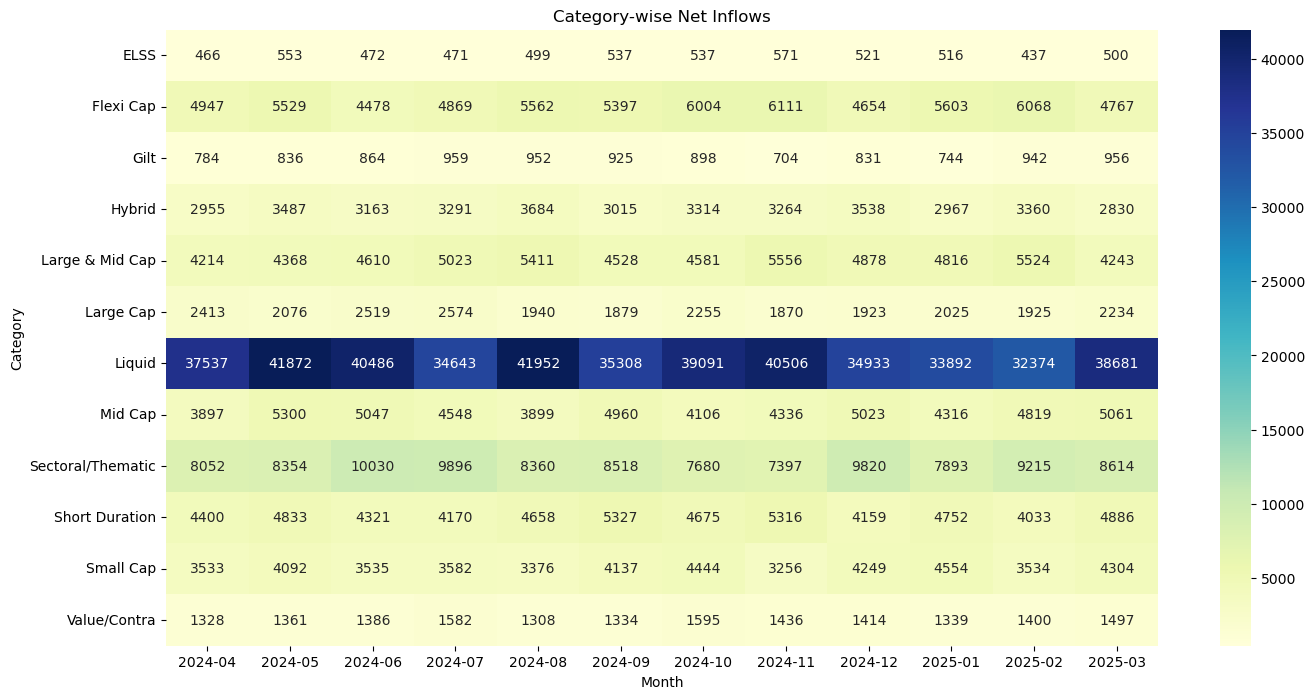

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title(
    "Category-wise Net Inflows"
)

plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

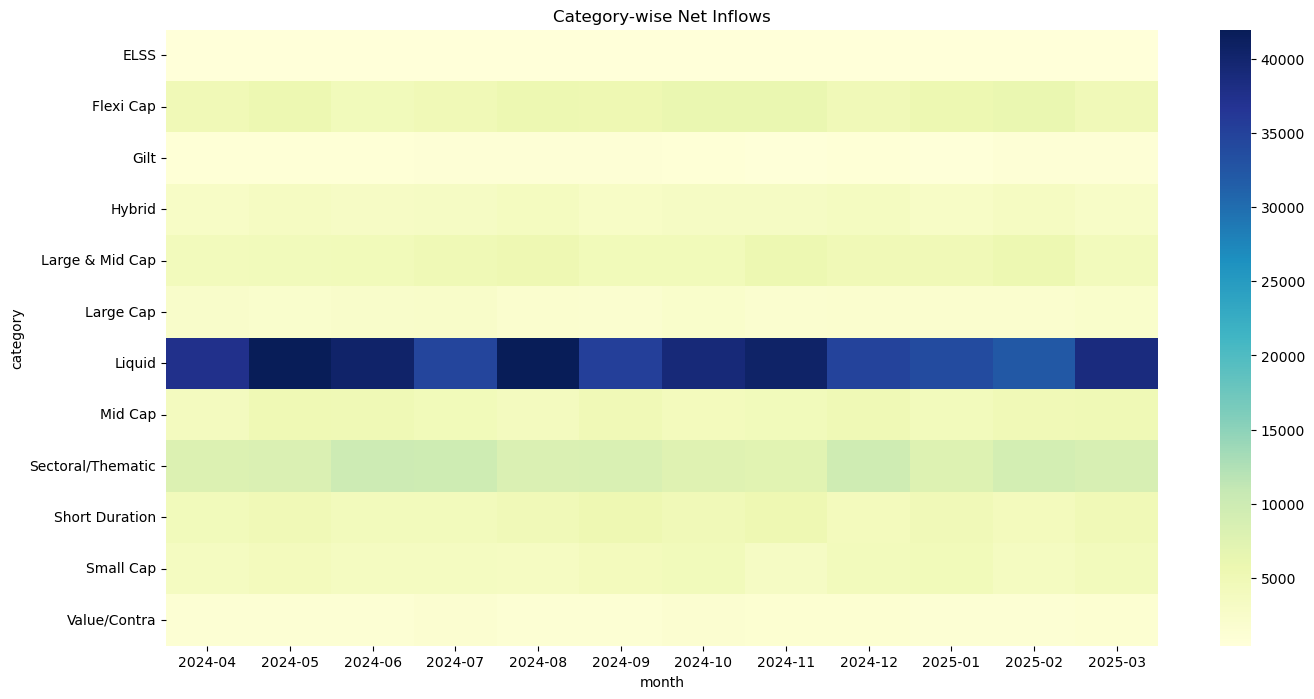

In [9]:
plt.figure(figsize=(16,8))

sns.heatmap(
    heatmap_data,
    cmap="YlGnBu"
)

plt.title(
    "Category-wise Net Inflows"
)

plt.savefig(
    "category_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [10]:
import os

print(
    os.path.exists(
        "category_heatmap.png"
    )
)

True


## Insight 4

Flexi Cap, Mid Cap and Large & Mid Cap categories attracted strong net inflows across most months, indicating higher investor preference toward diversified equity funds.

In [11]:
txn = pd.read_csv(
    "../../../data/processed/investor_transactions_clean.csv"
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [12]:
txn = pd.read_csv(
    "../../../data/processed/investor_transactions_clean.csv"
)

txn.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [13]:
txn.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')

In [14]:
age_counts = txn["age_group"].value_counts()

age_counts

age_group
26-35    13463
36-45     8146
18-25     4916
46-55     3779
56+       2474
Name: count, dtype: int64

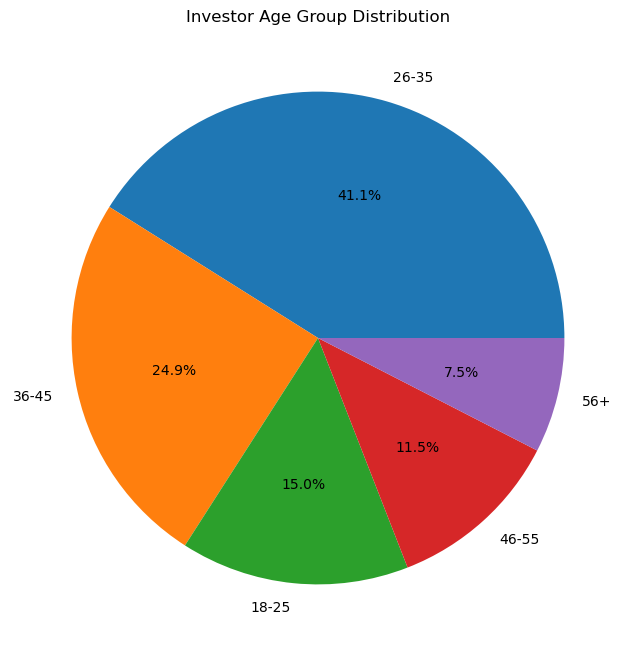

In [15]:
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Group Distribution"
)

plt.show()

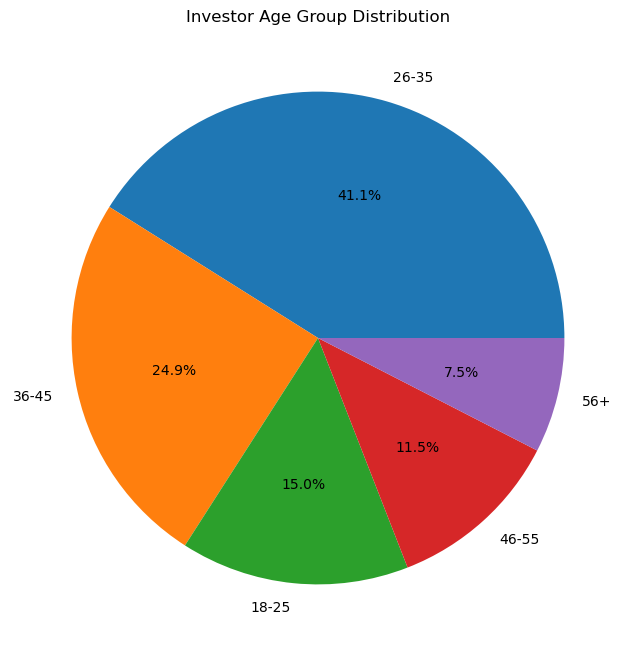

In [16]:
plt.figure(figsize=(8,8))

plt.pie(
    age_counts,
    labels=age_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Group Distribution"
)

plt.savefig(
    "age_group_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [17]:
gender_counts = txn["gender"].value_counts()

gender_counts

gender
Male      21809
Female    10969
Name: count, dtype: int64

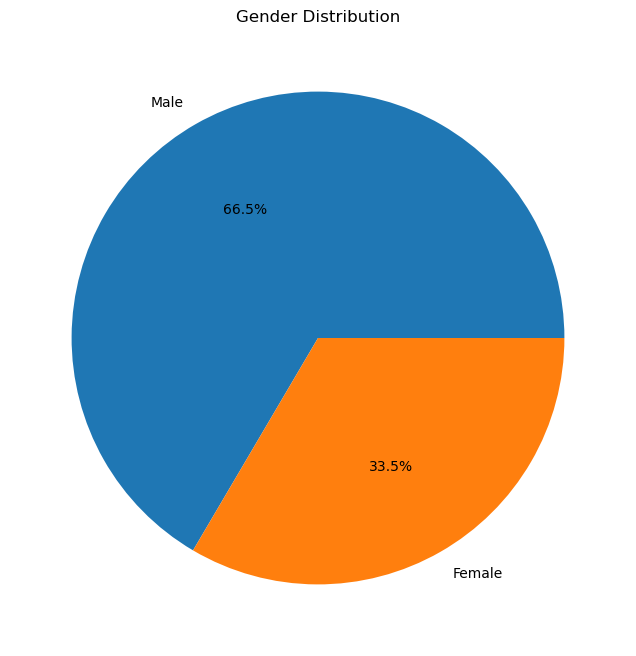

In [18]:
plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Gender Distribution"
)

plt.show()

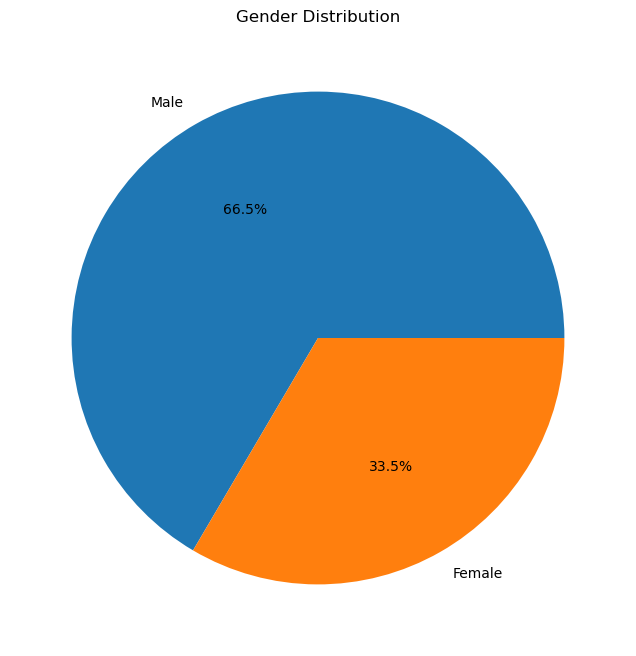

In [19]:
plt.figure(figsize=(8,8))

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "Gender Distribution"
)

plt.savefig(
    "gender_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [20]:
sip_txn = txn[
    txn["transaction_type"] == "SIP"
]

sip_txn.shape

(0, 13)

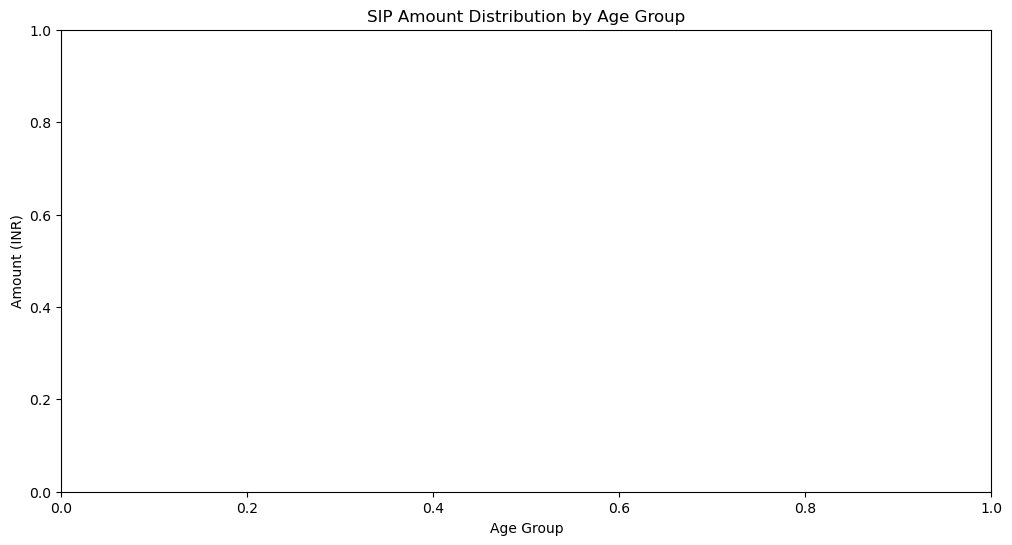

In [21]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group"
)

plt.xlabel("Age Group")
plt.ylabel("Amount (INR)")

plt.show()

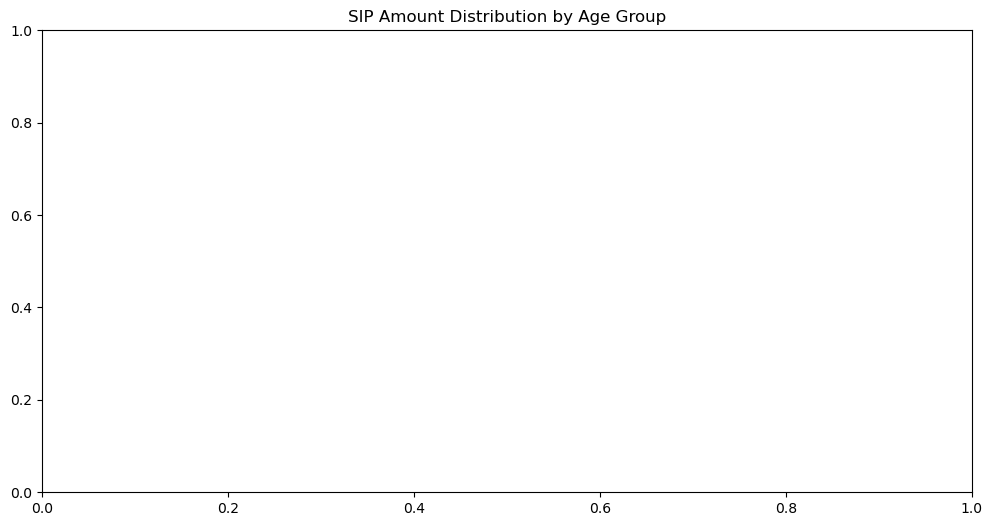

In [22]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=sip_txn,
    x="age_group",
    y="amount_inr"
)

plt.title(
    "SIP Amount Distribution by Age Group"
)

plt.savefig(
    "sip_boxplot_agegroup.png",
    bbox_inches="tight"
)

plt.show()

In [23]:
import os

print(os.path.exists("age_group_distribution.png"))
print(os.path.exists("gender_distribution.png"))
print(os.path.exists("sip_boxplot_agegroup.png"))

True
True
True


## Insight 5

The majority of investors belong to the most active working-age groups, indicating strong retail participation.

## Insight 6

Gender participation appears relatively balanced, though one segment contributes a larger share of total investors.


## Insight 7

SIP contribution amounts vary significantly across age groups, with some groups showing higher median investments.

In [24]:
txn

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,Sip,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,Sip,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,Sip,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending
...,...,...,...,...,...,...,...,...,...,...,...,...,...
32773,INV003340,2025-05-30,101207,Lumpsum,168029,Madhya Pradesh,Indore,T30,26-35,Male,22.5,Net Banking,Verified
32774,INV001838,2025-05-30,119093,Sip,2175,Uttar Pradesh,Kanpur,B30,46-55,Male,27.6,Mandate,Verified
32775,INV000074,2025-05-30,120504,Sip,25998,Rajasthan,Jaipur,T30,26-35,Female,8.4,UPI,Verified
32776,INV002929,2025-05-30,148568,Sip,459,West Bengal,Kolkata,T30,26-35,Male,13.0,Mandate,Verified


In [25]:
state_sip = (
    txn.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_sip.head(10)

state
Punjab            315780459
Tamil Nadu        315177237
Madhya Pradesh    308312493
Rajasthan         298645822
Gujarat           298358940
West Bengal       297182514
Telangana         290219284
Delhi             289633404
Uttar Pradesh     285368873
Haryana           279634354
Name: amount_inr, dtype: int64

In [26]:
state_sip = state_sip.reset_index()

state_sip.head()

,state,amount_inr
0,Punjab,315780459
1,Tamil Nadu,315177237
2,Madhya Pradesh,308312493
3,Rajasthan,298645822
4,Gujarat,298358940


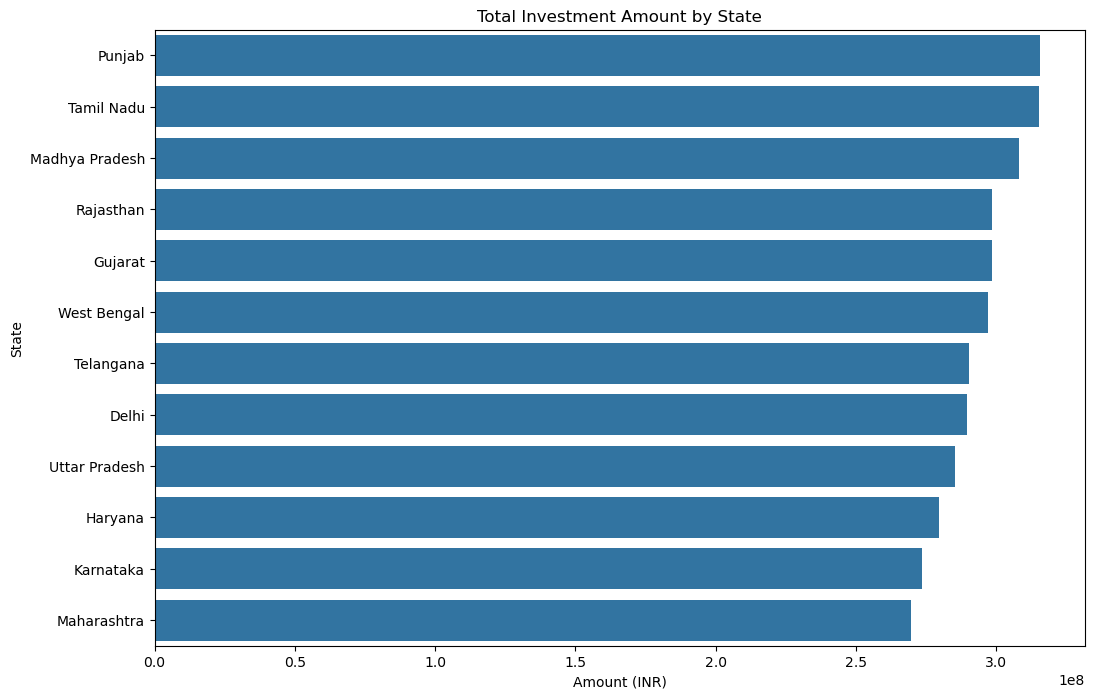

In [27]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("Total Investment Amount by State")

plt.xlabel("Amount (INR)")
plt.ylabel("State")

plt.show()

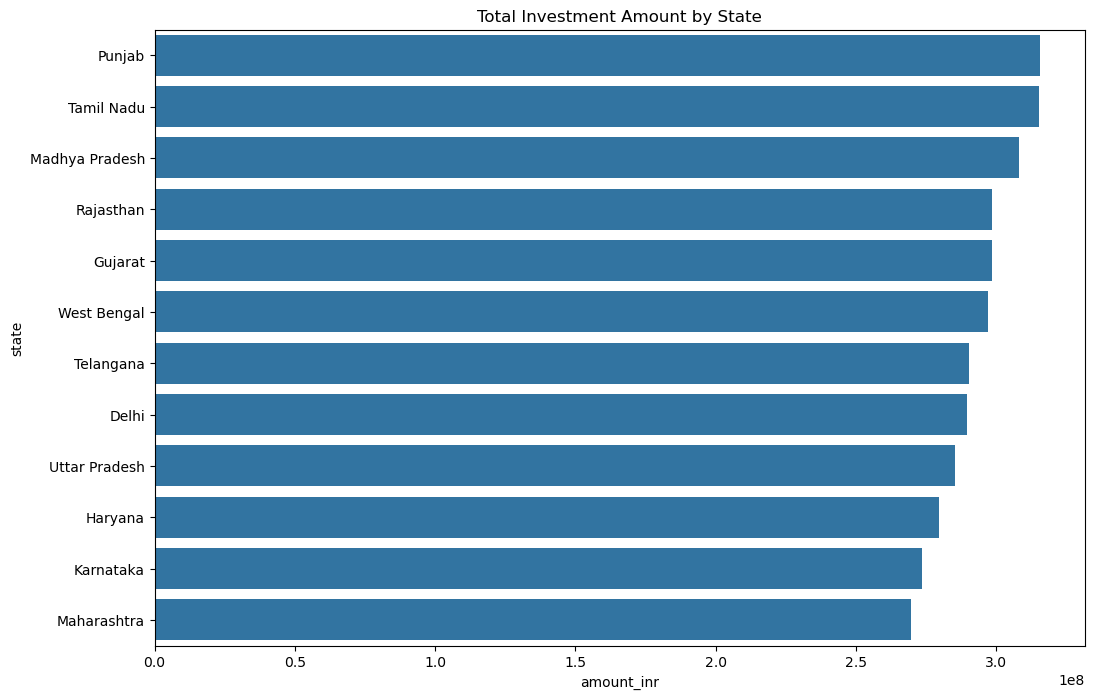

In [28]:
plt.figure(figsize=(12,8))

sns.barplot(
    data=state_sip,
    x="amount_inr",
    y="state"
)

plt.title("Total Investment Amount by State")

plt.savefig(
    "state_investment_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [29]:
tier_counts = txn["city_tier"].value_counts()

tier_counts

city_tier
T30    21719
B30    11059
Name: count, dtype: int64

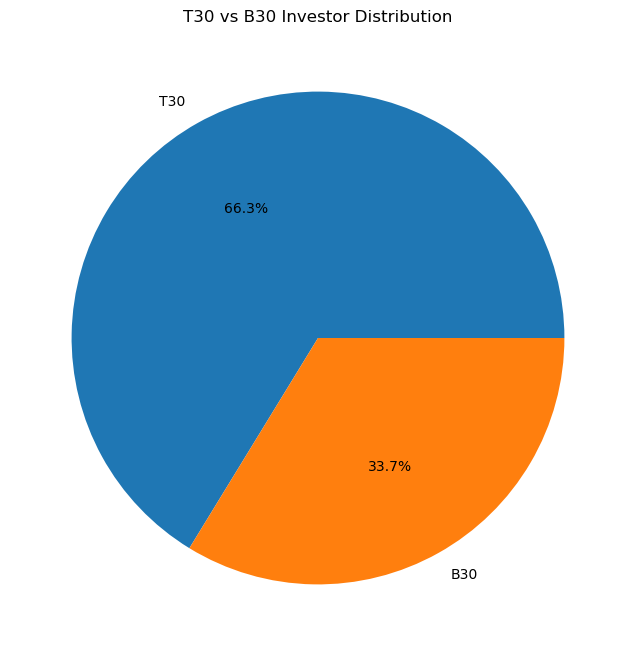

In [30]:
plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Investor Distribution"
)

plt.show()

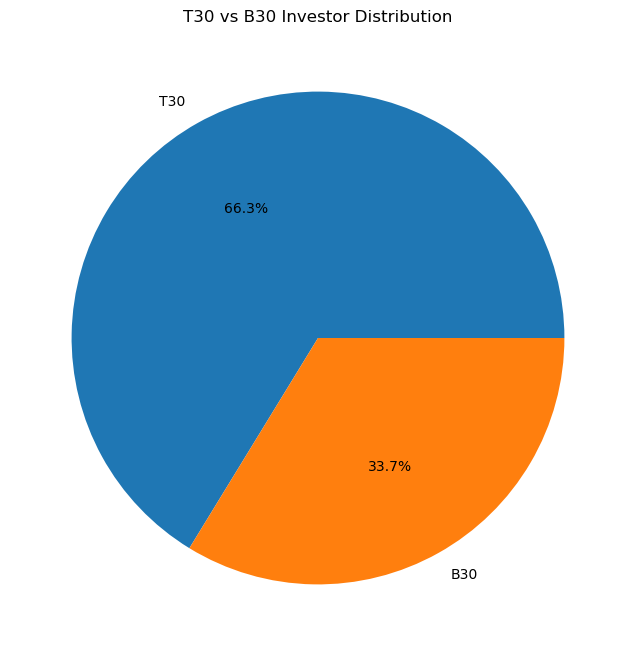

In [31]:
plt.figure(figsize=(8,8))

plt.pie(
    tier_counts,
    labels=tier_counts.index,
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 Investor Distribution"
)

plt.savefig(
    "t30_b30_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [32]:
import os

print(os.path.exists("state_investment_distribution.png"))
print(os.path.exists("t30_b30_distribution.png"))

True
True


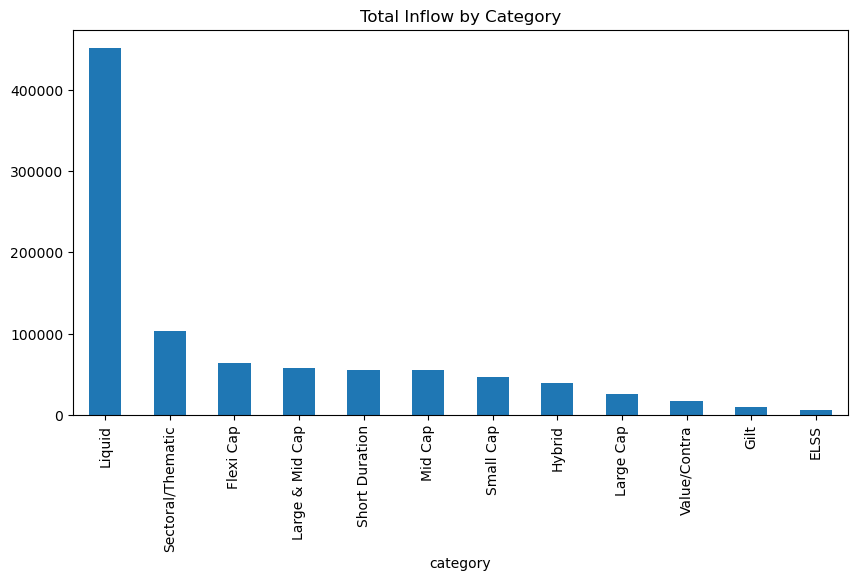

In [73]:
cat = pd.read_csv(
    "../../../data/raw/05_category_inflows.csv"
)

top_cat = (
    cat.groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

top_cat.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title(
    "Total Inflow by Category"
)

plt.savefig(
    "category_inflow_bar.png"
)

plt.show()

## Insight 8

A few large states contribute the majority of total mutual fund investments, indicating concentration of investor participation.

## Insight 9

T30 cities account for a significant share of investors, though B30 participation continues to grow and broaden mutual fund penetration.

In [33]:
folio = pd.read_csv(
    "../../../data/raw/06_industry_folio_count.csv"
)

folio.head()

,month,total_folios_crore,equity_folios_crore,debt_folios_crore,hybrid_folios_crore,others_folios_crore
0,2022-01,13.26,9.28,1.86,0.80,1.33
1,2022-04,13.91,9.74,1.95,0.83,1.39
2,2022-07,13.85,9.69,1.94,0.83,1.38
3,2022-10,14.12,9.88,1.98,0.85,1.41
4,2023-01,14.81,10.37,2.07,0.89,1.48


In [34]:
folio["month"] = pd.to_datetime(
    folio["month"]
)

folio.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   month                21 non-null     datetime64[ns]
 1   total_folios_crore   21 non-null     float64       
 2   equity_folios_crore  21 non-null     float64       
 3   debt_folios_crore    21 non-null     float64       
 4   hybrid_folios_crore  21 non-null     float64       
 5   others_folios_crore  21 non-null     float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 1.1 KB


In [35]:
folio[[
    "month",
    "total_folios_crore"
]].head()

,month,total_folios_crore
0,2022-01-01,13.26
1,2022-04-01,13.91
2,2022-07-01,13.85
3,2022-10-01,14.12
4,2023-01-01,14.81


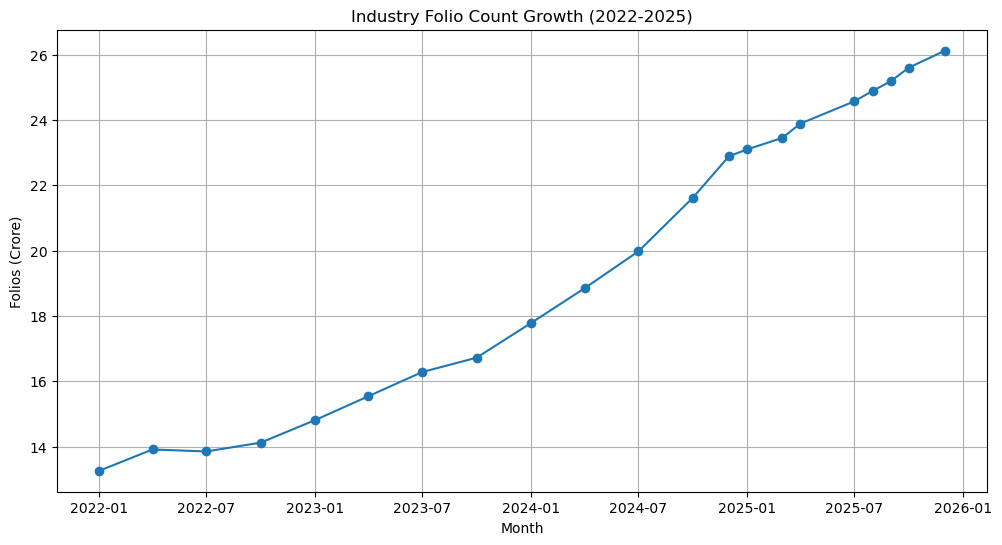

In [36]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title(
    "Industry Folio Count Growth (2022-2025)"
)

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.show()

In [37]:
folio.loc[
    folio["total_folios_crore"].idxmax()
]

month                  2025-12-01 00:00:00
total_folios_crore                   26.12
equity_folios_crore                  18.28
debt_folios_crore                     3.66
hybrid_folios_crore                   1.57
others_folios_crore                   2.61
Name: 20, dtype: object

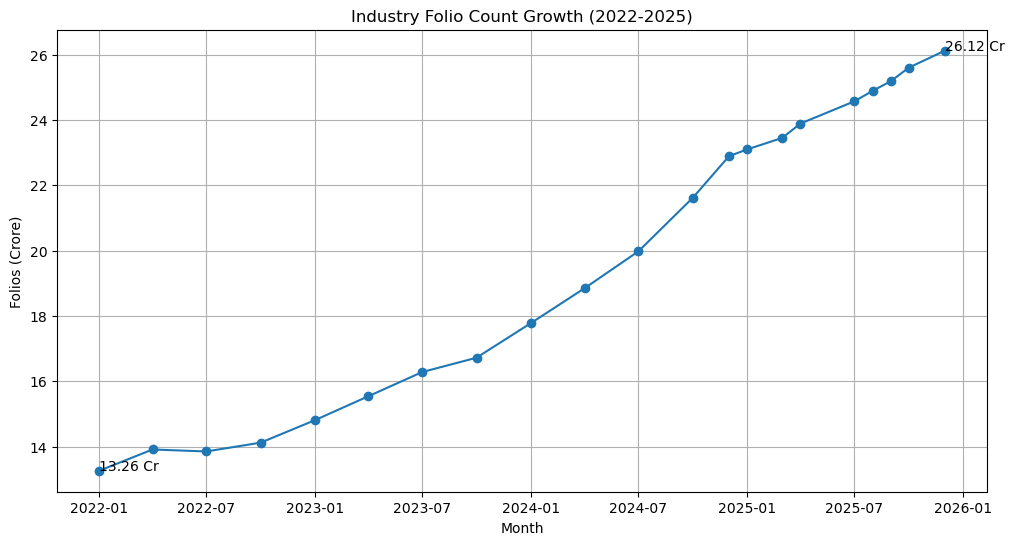

In [38]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.annotate(
    "13.26 Cr",
    (
        folio["month"].iloc[0],
        folio["total_folios_crore"].iloc[0]
    )
)

plt.annotate(
    "26.12 Cr",
    (
        folio["month"].iloc[-1],
        folio["total_folios_crore"].iloc[-1]
    )
)

plt.title(
    "Industry Folio Count Growth (2022-2025)"
)

plt.xlabel("Month")
plt.ylabel("Folios (Crore)")

plt.grid(True)

plt.show()

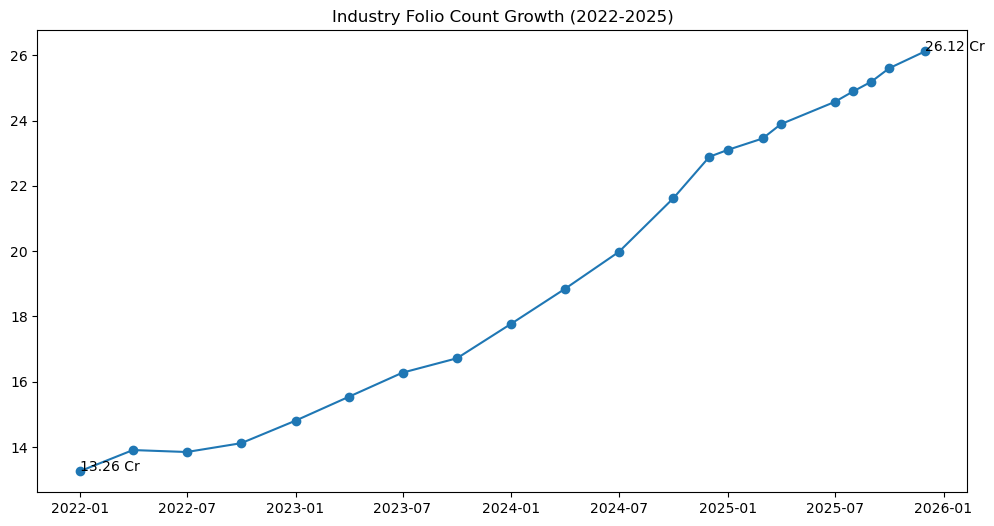

In [39]:
plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.annotate(
    "13.26 Cr",
    (
        folio["month"].iloc[0],
        folio["total_folios_crore"].iloc[0]
    )
)

plt.annotate(
    "26.12 Cr",
    (
        folio["month"].iloc[-1],
        folio["total_folios_crore"].iloc[-1]
    )
)

plt.title(
    "Industry Folio Count Growth (2022-2025)"
)

plt.savefig(
    "folio_growth.png",
    bbox_inches="tight"
)

plt.show()

In [40]:
import os

print(
    os.path.exists(
        "folio_growth.png"
    )
)

True


## Insight 10

Industry folio count nearly doubled from 13.26 crore in January 2022 to over 26 crore by the end of 2025, highlighting rapid growth in retail investor participation.

In [41]:
folio.shape

(21, 6)

In [42]:
nav = pd.read_csv(
    "../../../data/processed/nav_history_clean.csv"
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [43]:
nav["date"] = pd.to_datetime(
    nav["date"]
)

nav.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   amfi_code  46000 non-null  int64         
 1   date       46000 non-null  datetime64[ns]
 2   nav        46000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 1.1 MB


In [44]:
top_funds = (
    nav["amfi_code"]
    .unique()[:10]
)

top_funds

array([100016, 100025, 100033, 101206, 101207, 101208, 102885, 102886,
       102887, 118632], dtype=int64)

In [45]:
nav_10 = nav[
    nav["amfi_code"].isin(top_funds)
]

nav_10.shape

(11500, 3)

In [46]:
nav_pivot = nav_10.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

nav_pivot.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,520.4608,26.3169,107.3758,305.0996,38.5736,310.7415,89.8728,119.2905,191.0721,42.8339
2022-01-04,515.0971,26.2234,105.9447,305.4514,38.1545,310.6977,90.8724,120.6402,189.0737,42.8033
2022-01-05,521.7239,26.2221,105.4800,306.6324,38.1775,310.8165,90.1565,121.4580,188.0701,43.0564
2022-01-06,515.7880,26.1728,104.9350,305.9800,37.0665,310.7719,91.5338,125.2386,190.4545,43.2088
2022-01-07,515.1639,26.2261,104.3318,304.0480,37.9845,310.8388,90.6762,124.1321,187.3124,42.9585


In [47]:
returns = nav_pivot.pct_change()

returns.head()

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
date,,,,,,,,,,
2022-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-04,-0.010306,-0.003553,-0.013328,0.001153,-0.010865,-0.000141,0.011122,0.011314,-0.010459,-0.000714
2022-01-05,0.012865,-0.000050,-0.004386,0.003866,0.000603,0.000382,-0.007878,0.006779,-0.005308,0.005913
2022-01-06,-0.011377,-0.001880,-0.005167,-0.002128,-0.029101,-0.000143,0.015277,0.031127,0.012678,0.003540
2022-01-07,-0.001210,0.002036,-0.005748,-0.006314,0.024766,0.000215,-0.009369,-0.008835,-0.016498,-0.005793


In [48]:
returns = returns.dropna()

returns.shape

(1149, 10)

In [49]:
corr_matrix = returns.corr()

corr_matrix

amfi_code,100016,100025,100033,101206,101207,101208,102885,102886,102887,118632
amfi_code,,,,,,,,,,
100016,1.000000,0.045567,-0.000006,0.027747,0.016053,-0.033773,-0.093533,-0.005867,-0.023316,-0.026781
100025,0.045567,1.000000,0.002150,0.023769,-0.006710,0.018455,-0.001038,0.013754,-0.005648,-0.014166
100033,-0.000006,0.002150,1.000000,-0.018079,0.000351,0.007864,-0.034228,-0.018166,-0.036647,-0.013318
101206,0.027747,0.023769,-0.018079,1.000000,0.010202,-0.027230,0.001570,0.007229,-0.006490,-0.005432
101207,0.016053,-0.006710,0.000351,0.010202,1.000000,-0.007530,-0.005929,0.004860,0.002304,0.043384
101208,-0.033773,0.018455,0.007864,-0.027230,-0.007530,1.000000,-0.001436,0.014307,0.036547,0.003507
102885,-0.093533,-0.001038,-0.034228,0.001570,-0.005929,-0.001436,1.000000,0.020691,-0.036704,-0.000285
102886,-0.005867,0.013754,-0.018166,0.007229,0.004860,0.014307,0.020691,1.000000,-0.007865,-0.039886
102887,-0.023316,-0.005648,-0.036647,-0.006490,0.002304,0.036547,-0.036704,-0.007865,1.000000,0.001248


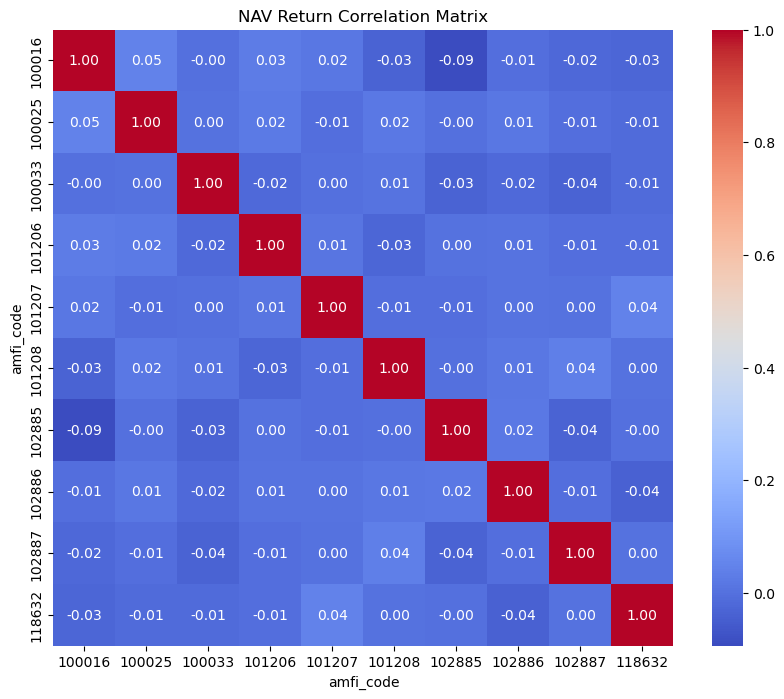

In [50]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.show()

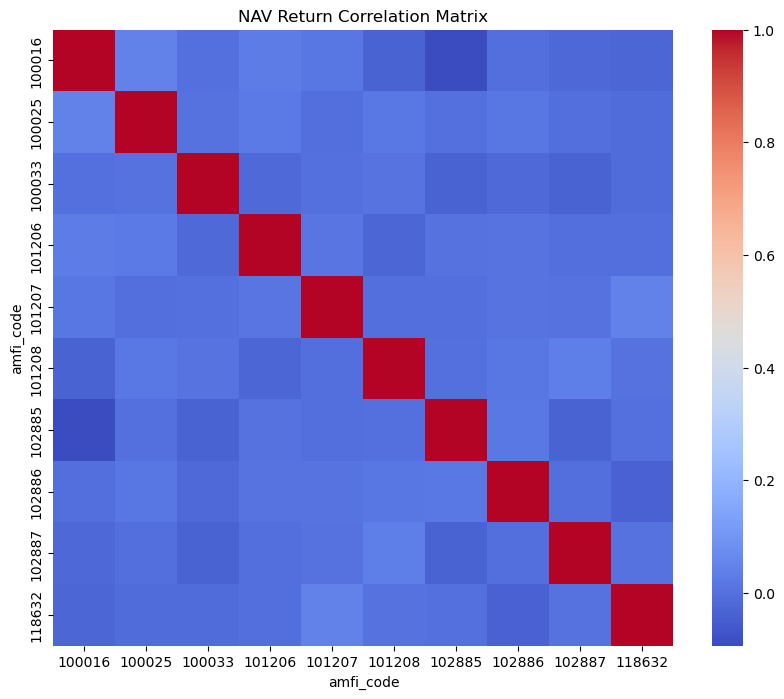

In [51]:
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title(
    "NAV Return Correlation Matrix"
)

plt.savefig(
    "nav_correlation_heatmap.png",
    bbox_inches="tight"
)

plt.show()

In [52]:
import os

print(
    os.path.exists(
        "nav_correlation_heatmap.png"
    )
)

True


## Insight 11

Most equity mutual fund schemes exhibit positive return correlations, reflecting broad market influence on NAV movements.

In [54]:
holdings = pd.read_csv(
    "../../../data/raw/09_portfolio_holdings.csv"
)

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [55]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [56]:
holdings.shape

(322, 8)

In [57]:
sector_alloc = (
    holdings.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

sector_alloc

sector
Banking           652.26
IT                455.47
Pharma            407.45
Automobile        323.65
Utilities         265.54
FMCG              229.11
Infrastructure    192.16
Diversified       169.23
Telecom           145.62
Consumer Goods    127.61
NBFC              119.09
Energy            117.91
Cement            105.03
Paints             89.86
Name: weight_pct, dtype: float64

In [58]:
sector_alloc = sector_alloc.reset_index()

sector_alloc.head()

,sector,weight_pct
0,Banking,652.26
1,IT,455.47
2,Pharma,407.45
3,Automobile,323.65
4,Utilities,265.54


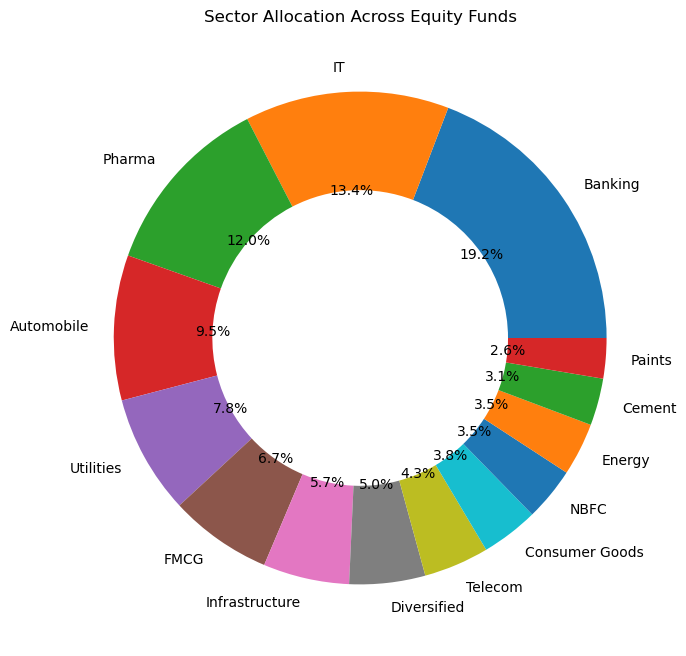

In [59]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_alloc["weight_pct"],
    labels=sector_alloc["sector"],
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title(
    "Sector Allocation Across Equity Funds"
)

plt.show()

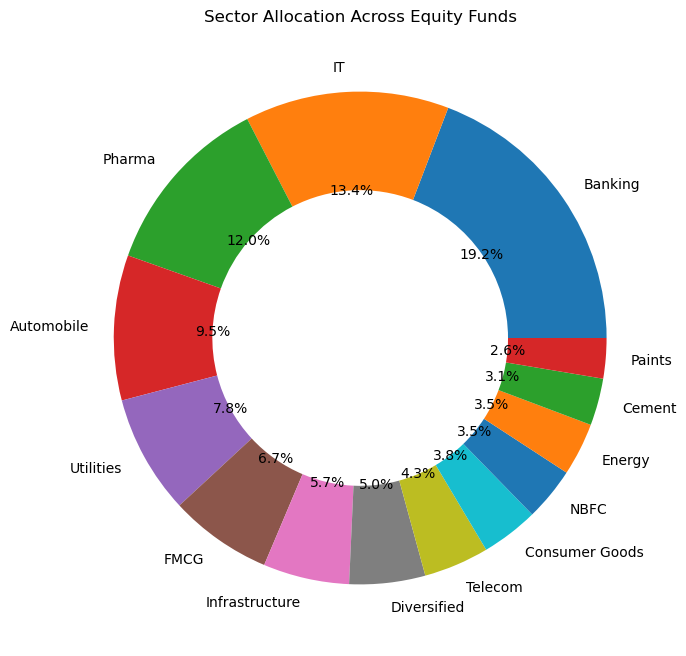

In [60]:
plt.figure(figsize=(8,8))

plt.pie(
    sector_alloc["weight_pct"],
    labels=sector_alloc["sector"],
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title(
    "Sector Allocation Across Equity Funds"
)

plt.savefig(
    "sector_allocation_donut.png",
    bbox_inches="tight"
)

plt.show()

In [61]:
import os

print(
    os.path.exists(
        "sector_allocation_donut.png"
    )
)

True


## Insight 12

Financials, IT, and Energy sectors account for a significant portion of equity mutual fund portfolios, reflecting their importance in the Indian equity market.

In [62]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='object')

In [70]:
import os

pngs = [f for f in os.listdir() if f.endswith(".png")]

print(len(pngs))
print(pngs)

10
['age_group_distribution.png', 'aum_growth.png', 'category_heatmap.png', 'folio_growth.png', 'gender_distribution.png', 'nav_correlation_heatmap.png', 'sector_allocation_donut.png', 'sip_boxplot_agegroup.png', 'state_investment_distribution.png', 't30_b30_distribution.png']


In [79]:
import os

pngs = [f for f in os.listdir() if f.endswith(".png")]

print(len(pngs))

14


In [80]:
txn["transaction_type"].value_counts()

transaction_type
Sip           19716
Lumpsum        8095
Redemption     4967
Name: count, dtype: int64

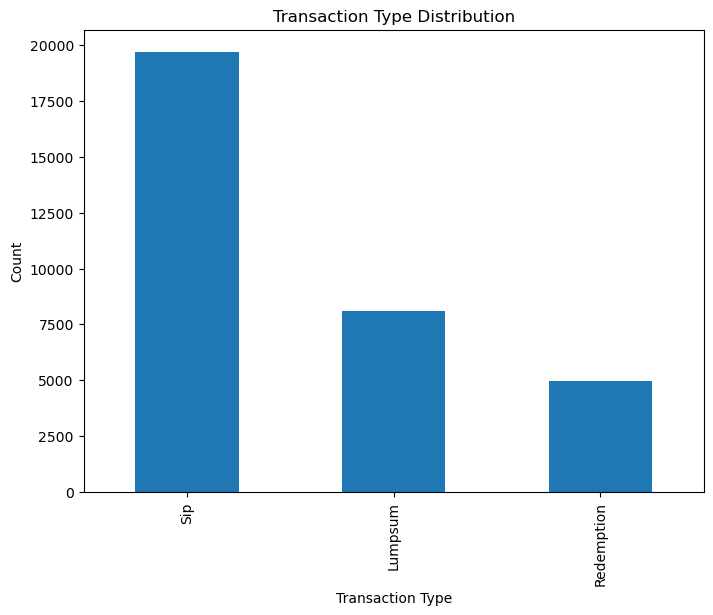

In [81]:
plt.figure(figsize=(8,6))

txn["transaction_type"].value_counts().plot(
    kind="bar"
)

plt.title(
    "Transaction Type Distribution"
)

plt.xlabel(
    "Transaction Type"
)

plt.ylabel(
    "Count"
)

plt.savefig(
    "transaction_type_distribution.png",
    bbox_inches="tight"
)

plt.show()

In [82]:
import os

pngs = [f for f in os.listdir() if f.endswith(".png")]

print(len(pngs))

15


# Key EDA Findings

1. NAVs showed sustained growth through most of the period.
2. SBI Mutual Fund maintained the largest AUM among major fund houses.
3. SIP inflows reached record highs toward the end of 2025.
4. Flexi Cap and Mid Cap funds attracted strong investor inflows.
5. Working-age investors formed the largest investor segment.
6. Gender participation remained broadly balanced.
7. SIP contribution size varied significantly by age group.
8. Investments were concentrated in a few major states.
9. T30 cities contributed a large share of investments.
10. Folio counts nearly doubled between 2022 and 2025.